In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Środowisko:

In [23]:
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

class MultiTreasureHunterMDP:
    def __init__(self, map_lines):
        self.original_map = [list(row) for row in map_lines]
        self.height = len(self.original_map)
        self.width = len(self.original_map[0])
        self.treasures = set()
        self.bases = {}
        self.agent_pos = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}

    def reset(self):
        self.map = [row[:] for row in self.original_map]
        self.treasures = set()
        self.bases = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}

        # Najpierw znajdź skarby i bazy - sprawdzamy dwuznakowe oznaczenia
        for y in range(self.height):
            for x in range(self.width):
                tile = self.map[y][x]
                if tile == 'T':
                    self.treasures.add((x, y))
                elif tile == 'S':
                    # Sprawdź następny znak
                    if x + 1 < self.width:
                        next_tile = self.map[y][x + 1]
                        if next_tile in ['1', '2']:
                            self.bases[next_tile] = (x, y)
                            self.map[y][x] = '.'
                            self.map[y][x + 1] = '.'

        # Walidacja: obie bazy muszą istnieć
        if '1' not in self.bases or '2' not in self.bases:
            raise ValueError("Mapa musi zawierać S1 i S2!")

        # Teraz ustaw pozycje agentów
        self.agent_pos['1'] = self.bases['1']
        self.agent_pos['2'] = self.bases['2']

        return self._get_state()

    def _get_state(self):
        return (
            self.agent_pos['1'],
            self.agent_pos['2'],
            frozenset(self.treasures),
            self.agent_holding['1'],
            self.agent_holding['2']
        )

    def get_possible_actions(self):
        """Zwraca akcje dla każdego agenta (niezależnie od stanu)"""
        return [LEFT, DOWN, RIGHT, UP]

    def _move(self, agent_id, action):
        x, y = self.agent_pos[agent_id]
        dx, dy = ACTIONS[action]
        nx, ny = x + dx, y + dy

        # Granice
        if not (0 <= nx < self.width and 0 <= ny < self.height):
            return x, y
        # Ściana
        if self.map[ny][nx] == '#':
            return x, y
        # Kolizja z drugim agentem
        other_pos = self.agent_pos['2'] if agent_id == '1' else self.agent_pos['1']
        if (nx, ny) == other_pos:
            return x, y

        return nx, ny

    def step(self, action1, action2):
        rewards = {'1': 0.0, '2': 0.0}
        info = {}

        # Ruch
        self.agent_pos['1'] = self._move('1', action1)
        self.agent_pos['2'] = self._move('2', action2)
        rewards['1'] -= 1
        rewards['2'] -= 1

        # Interakcje
        for aid, pos in [('1', self.agent_pos['1']), ('2', self.agent_pos['2'])]:
            x, y = pos

            # Pułapka
            if self.map[y][x] == 'H':
                rewards[aid] = -30
                continue

            # Zbieranie skarbu
            if pos in self.treasures and not self.agent_holding[aid]:
                self.treasures.remove(pos)
                self.agent_holding[aid] = True
                rewards[aid] += 3
                info[f'{aid}_pick'] = True

            # Odkładanie w bazie
            if pos == self.bases[aid] and self.agent_holding[aid]:
                self.agent_holding[aid] = False
                self.agent_score[aid] += 3
                rewards[aid] += 5
                info[f'{aid}_deposit'] = True

        done = self._is_done()
        return self._get_state(), rewards, done, info

    def _is_done(self):
        trap1 = self.map[self.agent_pos['1'][1]][self.agent_pos['1'][0]] == 'H'
        trap2 = self.map[self.agent_pos['2'][1]][self.agent_pos['2'][0]] == 'H'
        no_treasure = len(self.treasures) == 0
        both_home = (
            self.agent_pos['1'] == self.bases['1'] and
            self.agent_pos['2'] == self.bases['2'] and
            not self.agent_holding['1'] and not self.agent_holding['2']
        )
        return (trap1 and trap2) or (no_treasure and both_home)

    def render(self):
        pass
        # grid = [row[:] for row in self.map]
        # for x, y in self.treasures:
        #     grid[y][x] = 'T'
        # p1, p2 = self.agent_pos['1'], self.agent_pos['2']
        # grid[p1[1]][p1[0]] = '★' if self.agent_holding['1'] else '1'
        # grid[p2[1]][p2[0]] = '★' if self.agent_holding['2'] else '2'

        # print("\n" + "="*40)
        # for row in grid:
        #     print(''.join(row))
        # print(f"Skarby: {len(self.treasures)} | Punkty: 1:{self.agent_score['1']}  2:{self.agent_score['2']}")
        # print(f"Trzyma: 1:{self.agent_holding['1']}  2:{self.agent_holding['2']}")
        # print("="*40)

In [24]:
import random
from collections import defaultdict


class DQLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Double Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)
        """

        self.get_legal_actions = get_legal_actions
        self._qvaluesA = defaultdict(lambda: defaultdict(lambda: 0))
        self._qvaluesB = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        
    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvaluesA[state][action] + self._qvaluesB[state][action] 


    #---------------------START OF YOUR CODE---------------------#

    def get_best_action(self, state, table='A'):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None
        
        possible_actions_values = {}
        for a in possible_actions:
            if table == 'A':
                possible_actions_values[a] = self._qvaluesA[state][a]
            else:
                possible_actions_values[a] = self._qvaluesB[state][a]
            # possible_actions_values[a] = self.get_qvalue(state, a)

        max_qvalue = max(possible_actions_values.values())
        
        # wybierz najlepszą akcję losowo (jesli jest jedna to tą jedną)
        best_action = random.choice([a for a, v in possible_actions_values.items() if v == max_qvalue])
        
        return best_action

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        # curr_qvalue = self.get_qvalue(state, action)
        # next_action = self.get_best_action(next_state,)

        p = random.uniform(0, 1)
        if p < 0.5:
            next_action = self.get_best_action(next_state, table='A')
            next_qvalue = self._qvaluesB[next_state][next_action]
            
            res = learning_rate * (reward + gamma * next_qvalue - self._qvaluesA[state][action])
            self._qvaluesA[state][action] += res
        else:
            next_action = self.get_best_action(next_state, table='B')
            next_qvalue = self._qvaluesA[next_state][next_action]
            
            res = learning_rate * (reward + gamma * next_qvalue - self._qvaluesB[state][action])
            self._qvaluesB[state][action] += res


    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        epsilon = self.epsilon

        p = random.uniform(0, 1)
        if 1 - epsilon < p: #randomowa akcja z prawdopodobienstwem epsilon (eksploracja)
            chosen_action = random.choice(possible_actions)
        else: # najlepsza akcja z prawdopodobienstwem 1-epsilon (eksploatacja)
            chosen_action = self.get_best_action(state)        

        return chosen_action

    def reset(self):
        """Reset nie jest potrzebny dla Double Q-Learning, ale dodajemy dla kompatybilności"""
        pass

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0


In [25]:
import random
from collections import defaultdict


class SARSALambdaAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions, lambda_value):
        """
        SARSA Lambda Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount
        self.lambda_value = lambda_value

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    def reset(self):
        self._evalues = defaultdict(lambda: defaultdict(lambda: 0))

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0
        
        values = []
        for a in possible_actions:
            values.append(self.get_qvalue(state, a))


        return max(values)

    def update(self, state, action, reward, next_state):
        """
        You should do your SARSA-Lambda update here:
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        curr_qvalue = self.get_qvalue(state, action)
        next_action = self.get_best_action(next_state)
        next_qvalue = self.get_qvalue(next_state, next_action)

        sigma = reward + gamma * next_qvalue - curr_qvalue
        self._evalues[state][action] = 1
        for s in self._evalues:
            for a in self._evalues[s]:
                old_qvalue = self.get_qvalue(s, a)

                res = old_qvalue + learning_rate * sigma * self._evalues[s][a]
                self.set_qvalue(s, a, res)
                self._evalues[s][a] = gamma * self.lambda_value * self._evalues[s][a]

        return next_action

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        possible_actions_values = {}
        for a in possible_actions:
            possible_actions_values[a] = self.get_qvalue(state, a)

        max_qvalue = max(possible_actions_values.values())

        best_action = random.choice([a for a, value in possible_actions_values.items() if value == max_qvalue])

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        p = random.uniform(0, 1)
        if 1 - epsilon < p:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)    

        return chosen_action

    def turn_off_learning(self):
        self.epsilon = 0
        self.alpha = 0

    def display_qvalues(self):
        for s in self._qvalues:
            print("State: " + str(s) + " " + str(self._qvalues[s]))


In [26]:
def play_and_train_multi(env, agent1, agent2, episodes=5000):
    rewards_history_agent1 = []
    rewards_history_agent2 = []
    scores_history_agent1 = []
    scores_history_agent2 = []

    for ep in range(episodes):
        state = env.reset()
        total_r1 = total_r2 = 0
        agent1.reset()
        agent2.reset()

        action1 = agent1.get_action(state)
        action2 = agent2.get_action(state)

        while True:
            next_state, rewards, done, _ = env.step(action1, action2)
            r1, r2 = rewards['1'], rewards['2']
            total_r1 += r1
            total_r2 += r2

            # Każdy agent uczy się na SWOICH nagrodach (konkurencja)
            next_action1 = agent1.update(state, action1, r1, next_state)
            next_action2 = agent2.update(state, action2, r2, next_state)

            action1 = next_action1 or agent1.get_action(next_state)
            action2 = next_action2 or agent2.get_action(next_state)
            state = next_state

            if done:
                break

        # Zapisujemy wyniki OSOBNO dla każdego agenta
        score1 = env.agent_score['1']
        score2 = env.agent_score['2']
        
        rewards_history_agent1.append(total_r1)
        rewards_history_agent2.append(total_r2)
        scores_history_agent1.append(score1)
        scores_history_agent2.append(score2)

        if (ep + 1) % 100 == 0:
            print(f"Epizod {ep+1:4d} | Agent1: R={total_r1:6.1f} P={score1} | Agent2: R={total_r2:6.1f} P={score2}")

    return (rewards_history_agent1, rewards_history_agent2, 
            scores_history_agent1, scores_history_agent2)

In [27]:
def test_policy(env, agent1, agent2, episodes=3):
    agent1.turn_off_learning()
    agent2.turn_off_learning()

    for ep in range(episodes):
        state = env.reset()
        print(f"\n{'='*20} GRA TESTOWA {ep+1} {'='*20}")
        env.render()
        step = 0

        while True:
            a1 = agent1.get_action(state)
            a2 = agent2.get_action(state)
            state, rewards, done, info = env.step(a1, a2)
            step += 1
            print(f"Krok {step:2d}: A1={a1}, A2={a2} → R1={rewards['1']:+.1f}, R2={rewards['2']:+.1f}")
            env.render()
            if done:
                print(f"--- KONIEC GRY {ep+1} ---")
                break

=== ROZPOCZYNAM TRENING (1000 epizodów) ===
Epizod  100 | Agent1: R=-1181.0 P=6 | Agent2: R=-1537.0 P=3
Epizod  100 | Agent1: R=-1181.0 P=6 | Agent2: R=-1537.0 P=3
Epizod  200 | Agent1: R=-282.0 P=3 | Agent2: R=-680.0 P=6
Epizod  200 | Agent1: R=-282.0 P=3 | Agent2: R=-680.0 P=6
Epizod  300 | Agent1: R=-517.0 P=3 | Agent2: R=-712.0 P=6
Epizod  300 | Agent1: R=-517.0 P=3 | Agent2: R=-712.0 P=6
Epizod  400 | Agent1: R=-1138.0 P=6 | Agent2: R=-1639.0 P=3
Epizod  400 | Agent1: R=-1138.0 P=6 | Agent2: R=-1639.0 P=3
Epizod  500 | Agent1: R=-488.0 P=3 | Agent2: R=-538.0 P=6
Epizod  500 | Agent1: R=-488.0 P=3 | Agent2: R=-538.0 P=6
Epizod  600 | Agent1: R=-230.0 P=6 | Agent2: R=-325.0 P=3
Epizod  600 | Agent1: R=-230.0 P=6 | Agent2: R=-325.0 P=3
Epizod  700 | Agent1: R=-139.0 P=3 | Agent2: R=-131.0 P=6
Epizod  700 | Agent1: R=-139.0 P=3 | Agent2: R=-131.0 P=6
Epizod  800 | Agent1: R=-140.0 P=6 | Agent2: R=-119.0 P=3
Epizod  800 | Agent1: R=-140.0 P=6 | Agent2: R=-119.0 P=3
Epizod  900 | Agent1

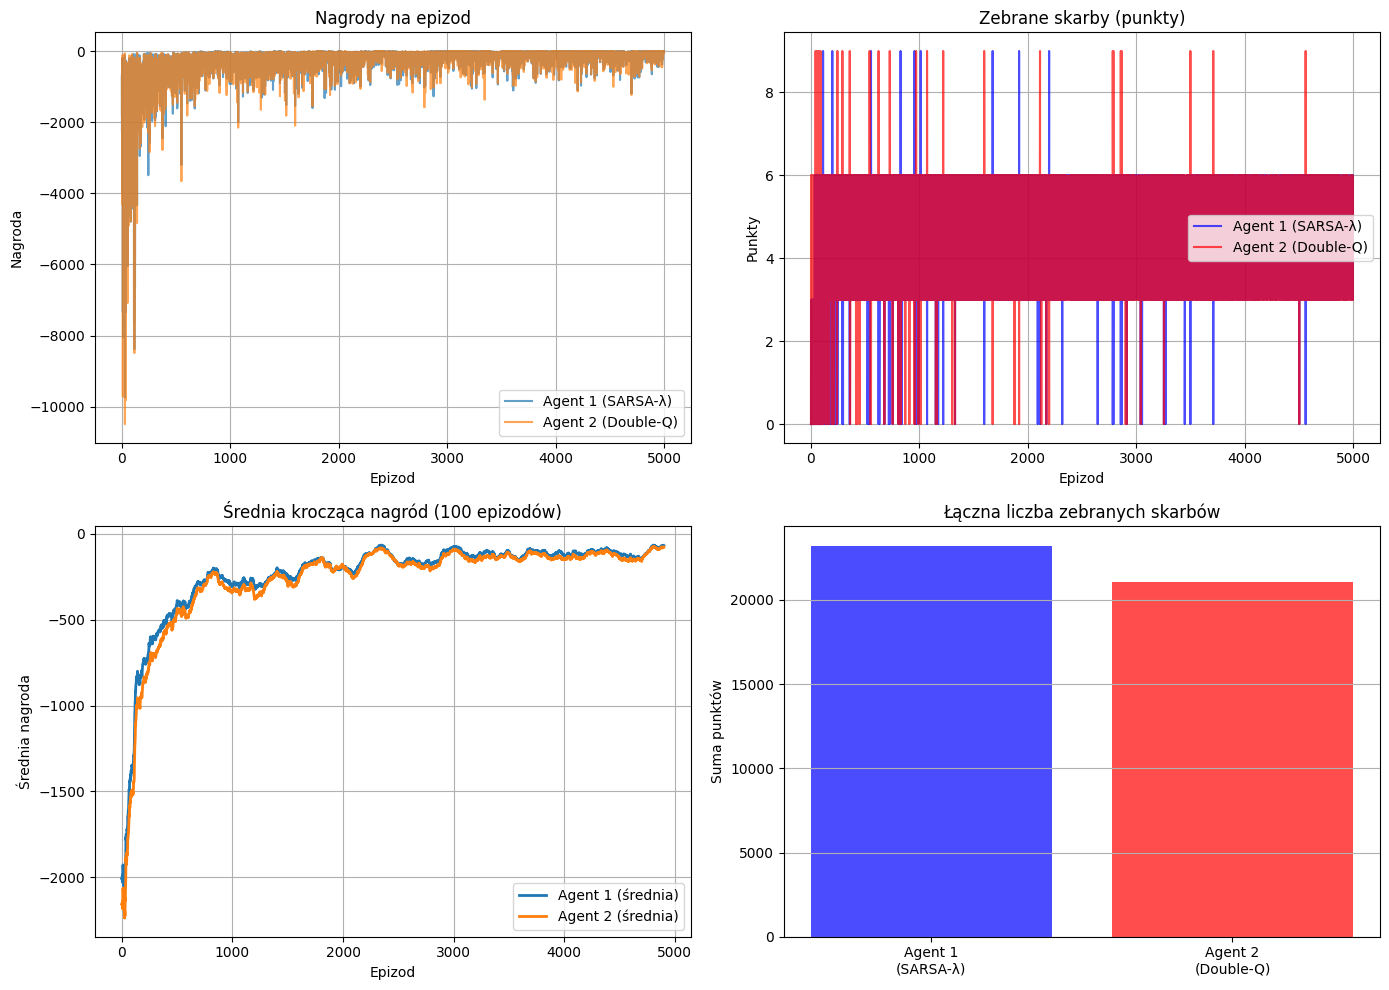


=== PODSUMOWANIE ===
Agent 1 (SARSA-λ):  Łącznie punktów: 23205, Średnia nagroda: -257.5
Agent 2 (Double-Q): Łącznie punktów: 21039, Średnia nagroda: -287.3

=== TESTOWANIE WYTRENOWANEJ POLITYKI ===

==================== GRA TESTOWA 1 ====================
Krok  1: A1=1, A2=0 → R1=-1.0, R2=-1.0
Krok  2: A1=1, A2=0 → R1=+2.0, R2=-1.0
Krok  3: A1=3, A2=0 → R1=-1.0, R2=-1.0
Krok  4: A1=3, A2=3 → R1=+4.0, R2=+2.0
Krok  5: A1=3, A2=2 → R1=-1.0, R2=-1.0
Krok  6: A1=2, A2=2 → R1=-1.0, R2=-1.0
Krok  7: A1=2, A2=1 → R1=-1.0, R2=-1.0
Krok  8: A1=2, A2=2 → R1=-1.0, R2=+4.0
Krok  9: A1=2, A2=3 → R1=-1.0, R2=-1.0
Krok 10: A1=3, A2=0 → R1=-1.0, R2=-1.0
Krok 11: A1=2, A2=3 → R1=+2.0, R2=-1.0
Krok 12: A1=0, A2=0 → R1=-1.0, R2=-1.0
Krok 13: A1=0, A2=1 → R1=-1.0, R2=-1.0
Krok 14: A1=0, A2=1 → R1=-1.0, R2=-1.0
Krok 15: A1=0, A2=3 → R1=-1.0, R2=-1.0
Krok 16: A1=3, A2=0 → R1=-1.0, R2=-1.0
Krok 17: A1=1, A2=2 → R1=-1.0, R2=-1.0
Krok 18: A1=0, A2=0 → R1=-1.0, R2=-1.0
Krok 19: A1=1, A2=2 → R1=-1.0, R2=-1.0
Kr

In [28]:
MAP = [
    "S1...T....",
    "..#..#..#.",
    "T.......H.",
    "..#..T..#.",
    "....H...S2"
]

env = MultiTreasureHunterMDP(MAP)
state = env.reset()

# Agenci (możesz mieszać SARSAλ i Double Q)
agent1 = SARSALambdaAgent(
    alpha=0.1, epsilon=0.15, discount=0.99,
    get_legal_actions=lambda s: env.get_possible_actions(),
    lambda_value=0.9
)
agent2 = DQLearningAgent(
    alpha=0.1, epsilon=0.15, discount=0.99,
    get_legal_actions=lambda s: env.get_possible_actions()
)

print("=== ROZPOCZYNAM TRENING (1000 epizodów) ===")
rewards1, rewards2, scores1, scores2 = play_and_train_multi(env, agent1, agent2, episodes=5000)

# Wykresy porównawcze dla obu agentów
plt.figure(figsize=(14, 10))

# Nagrody agentów
plt.subplot(2, 2, 1)
plt.plot(rewards1, label='Agent 1 (SARSA-λ)', alpha=0.7)
plt.plot(rewards2, label='Agent 2 (Double-Q)', alpha=0.7)
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

# Punkty (zebrane skarby) agentów
plt.subplot(2, 2, 2)
plt.plot(scores1, label='Agent 1 (SARSA-λ)', color='blue', alpha=0.7)
plt.plot(scores2, label='Agent 2 (Double-Q)', color='red', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

# Średnie kroczące nagród (100 epizodów)
plt.subplot(2, 2, 3)
window = 100
if len(rewards1) >= window:
    avg_r1 = np.convolve(rewards1, np.ones(window)/window, mode='valid')
    avg_r2 = np.convolve(rewards2, np.ones(window)/window, mode='valid')
    plt.plot(avg_r1, label='Agent 1 (średnia)', linewidth=2)
    plt.plot(avg_r2, label='Agent 2 (średnia)', linewidth=2)
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

# Porównanie całkowitych punktów
plt.subplot(2, 2, 4)
total_scores1 = sum(scores1)
total_scores2 = sum(scores2)
plt.bar(['Agent 1\n(SARSA-λ)', 'Agent 2\n(Double-Q)'], 
        [total_scores1, total_scores2], 
        color=['blue', 'red'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"\n=== PODSUMOWANIE ===")
print(f"Agent 1 (SARSA-λ):  Łącznie punktów: {total_scores1}, Średnia nagroda: {np.mean(rewards1):.1f}")
print(f"Agent 2 (Double-Q): Łącznie punktów: {total_scores2}, Średnia nagroda: {np.mean(rewards2):.1f}")

print("\n=== TESTOWANIE WYTRENOWANEJ POLITYKI ===")
test_policy(env, agent1, agent2, episodes=3)